# 03-Pooling & Receptive Fields

In Lesson 02, we introduced the Convolution operation. We learned how sliding a mathematical kernel across an image allows a network to extract local features—like vertical and horizontal edges—while completely bypassing the catastrophic parameter explosion of fully connected layers.

However, Convolutions introduce a massive spatial footprint problem. If an input image contains millions of pixels, and we apply 64 different convolutional filters to extract 64 different feature maps, our data volume explodes. Furthermore, if an object shifts by a single pixel, the exact coordinate matching of a convolution changes completely.

To build robust, memory-efficient Computer Vision models, we must introduce two fundamental concepts: **Pooling** (for spatial compression and invariance) and the **Receptive Field** (the structural field of view).

Let's set up our PyTorch environment to master spatial subsampling on real data.

In [7]:
import torch
import torch.nn as nn
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Spatial Compression Environment Ready.")

✅ PyTorch Spatial Compression Environment Ready.


# 1. The Mathematics of Pooling (Subsampling)

Pooling is a non-parametric downsampling operation. Like a convolution, it utilizes a sliding window across the spatial dimensions (Height and Width) of a feature map. However, unlike a convolution, **Pooling contains zero learnable weights**. It applies a fixed, deterministic mathematical reduction to the values bounded by its window.

The two primary paradigms are **Max Pooling** and **Average Pooling**. Typically, modern architectures implement a window size ($K$) of $2 \times 2$ paired with a Stride ($S$) of $2$.

### The Spatial Halving Law

Recall our structural dimension formula from Lesson 02:


$$O_{size} = \lfloor \frac{W - K + 2P}{S} \rfloor + 1$$

If we feed a feature map of width $W = 100$ into a standard pooling layer where $K=2$, $P=0$, and $S=2$:


$$O_{size} = \lfloor \frac{100 - 2 + 0}{2} \rfloor + 1 = 49 + 1 = 50$$

By setting the stride exactly equal to the kernel size, the sliding window moves across the matrix with zero overlap. The height is cut exactly in half; the width is cut exactly in half. This violently discards **75% of the spatial pixels**, throwing away redundant data before it reaches the next layer.

# 2. Max Pooling & Translation Invariance

**Max Pooling** samples a local region and outputs strictly the maximum mathematical value within that neighborhood:


$$O_{i,j} = \max_{m,n} (I_{i+m, j+n})$$

**Why does this absolute value reduction work?**
A convolutional feature map represents the activation strength of a feature. A high number (e.g., $9.5$) indicates that a feature (like a cat's whisker) was strongly detected. Max Pooling passes that $9.5$ forward while completely ignoring the surrounding low activations (zeros).

This introduces **Translation Invariance**. If the cat shifts slightly to the right, the $9.5$ activation spike moves within the matrix. However, because it is still captured within the boundaries of the same $2 \times 2$ pooling window, the Max Pooling operation outputs the exact same $9.5$. The deeper layers still "see" the whisker, regardless of its exact pixel coordinates.

# 3. Average Pooling vs. Global Average Pooling (GAP)

**Average Pooling** calculates the arithmetic mean of the local window:


$$O_{i,j} = \frac{1}{K \times K} \sum_{m} \sum_{n} I_{i+m, j+n}$$

While Average Pooling was foundational in early architectures (like LeNet-5), it has been largely superseded by Max Pooling in internal feature-extraction layers because averaging tends to wash out sharp, highly contrasting edge features.

However, a massive variant called **Global Average Pooling (GAP)** is used at the absolute end of modern networks (like ResNet). Instead of a $2 \times 2$ window, GAP takes an entire remaining spatial feature map (e.g., $7 \times 7$) and collapses all 49 pixels into a single average value. This completely removes the need for heavy, overfitted `nn.Flatten` and `nn.Linear` layers before the final classification nodes.

# 4. The Receptive Field (The Field of View)

When you stack Convolutions and Pooling layers sequentially, a critical geometric phenomenon occurs: **The Receptive Field expands.**

The Receptive Field ($R$) is defined as the exact window of pixels in the *original, raw input image* that a single neuron in a deep layer can physically "see."

* **Input Image**: Receptive Field = $1 \times 1$
* **Layer 1 (Conv $3 \times 3$, Stride 1)**: One neuron looks at 9 pixels. $R = 3$.
* **Layer 2 (MaxPool $2 \times 2$, Stride 2)**: One neuron looks at 4 pixels of Layer 1. But because each of those 4 neurons looked at a $3 \times 3$ patch of the original image, the field of view expands.

### The Compounding Receptive Field Formula

The receptive field of a specific layer $k$ is calculated recursively using the kernel size ($K_k$) and the compounding stride product of all previous layers ($S_i$):


$$R_k = R_{k-1} + (K_k - 1) \prod_{i=1}^{k-1} S_i$$

**The Engineering Constraint:** If you are engineering a network to detect a large object (like an entire car) that spans $200 \times 200$ pixels in the input image, but your deep network layers only have a calculated Receptive Field of $15 \times 15$, the network is physically blind to the car. A terminal neuron will only see a small patch of steel or rubber. It cannot comprehend the macro-structure. You *must* use pooling layers to aggressively scale up the Receptive Field.

# 5. Implementing Spatial Subsampling in PyTorch

Let's load the `skimage` cat image, convert it to a 4D tensor, apply Max Pooling and Average Pooling, and visually analyze how the underlying matrix transformation affects edge fidelity and spatial dimensions.

--- 📊 Initial Spatial Dimension Audit ---
Original NumPy Shape: (300, 451, 3) (H, W, C)
PyTorch Input Tensor: torch.Size([1, 3, 300, 451]) [B, C, H, W]

--- 🔲 Post-Pooling Dimension Audit ---
Max-Pooled Tensor Shape: torch.Size([1, 3, 150, 225])
Avg-Pooled Tensor Shape: torch.Size([1, 3, 150, 225])
Insight: The spatial dimensions were cut exactly in half (300->150, 451->225).


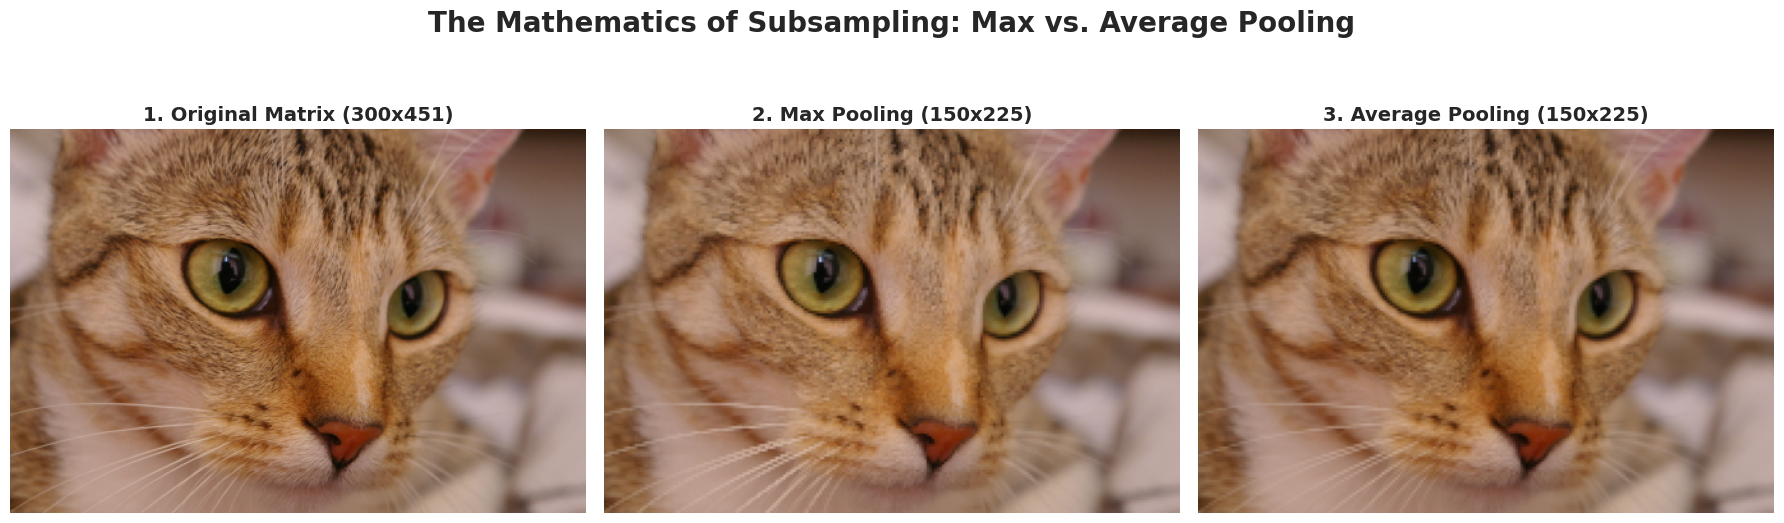

--- 🔬 Microscopic Resolution Verification ---
Original 10x10 Pixel Block Sample:
[[161 168 165]
 [161 163 167]
 [157 162 162]]

Max-Pooled 5x5 Compressed Equivalent Block:
[[0.659 0.655 0.643]
 [0.655 0.659 0.624]
 [0.647 0.714 0.682]]


In [8]:
# 1. Fetch and Formulate the Data Tensor
numpy_cat = data.chelsea() # High-res RGB cat image

# Normalize and convert to PyTorch shape [Batch, Channels, Height, Width]
transform = transforms.ToTensor()
cat_tensor = transform(numpy_cat).unsqueeze(0)

print("--- 📊 Initial Spatial Dimension Audit ---")
print(f"Original NumPy Shape: {numpy_cat.shape} (H, W, C)")
print(f"PyTorch Input Tensor: {cat_tensor.shape} [B, C, H, W]")

# 2. Instantiate Pooling Operations
# We configure a standard 2x2 window with a stride of 2 (No overlap, spatial halving)
max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool_layer = nn.AvgPool2d(kernel_size=2, stride=2)

# 3. Execute the Mathematical Subsampling
output_max = max_pool_layer(cat_tensor)
output_avg = avg_pool_layer(cat_tensor)

print("\n--- 🔲 Post-Pooling Dimension Audit ---")
print(f"Max-Pooled Tensor Shape: {output_max.shape}")
print(f"Avg-Pooled Tensor Shape: {output_avg.shape}")
print("Insight: The spatial dimensions were cut exactly in half (300->150, 451->225).")

# 4. Helper to transpose dimensions back to HWC for Matplotlib visualization
def to_numpy_hwc(tensor):
    return tensor.squeeze(0).permute(1, 2, 0).numpy()

# 5. Visualizing Spatial Downsampling Effects
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("The Mathematics of Subsampling: Max vs. Average Pooling", fontsize=20, fontweight='bold')

# Original Image
axes[0].imshow(numpy_cat)
axes[0].set_title(f"1. Original Matrix ({numpy_cat.shape[0]}x{numpy_cat.shape[1]})", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Max Pooling Result
axes[1].imshow(to_numpy_hwc(output_max))
axes[1].set_title(f"2. Max Pooling ({output_max.shape[2]}x{output_max.shape[3]})", fontweight='bold', fontsize=14)
axes[1].axis('off')

# Average Pooling Result
axes[2].imshow(to_numpy_hwc(output_avg))
axes[2].set_title(f"3. Average Pooling ({output_avg.shape[2]}x{output_avg.shape[3]})", fontweight='bold', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("--- 🔬 Microscopic Resolution Verification ---")
# Let's zoom into a tiny 10x10 patch of pixels around the cat's eye to see the mathematical degradation
zoom_orig = numpy_cat[100:110, 100:110, 0] # Red channel original
zoom_max  = output_max[0, 0, 50:55, 50:55].detach().numpy() # Red channel pooled

print("Original 10x10 Pixel Block Sample:")
print(zoom_orig[0:3, 0:3])
print("\nMax-Pooled 5x5 Compressed Equivalent Block:")
print(zoom_max[0:3, 0:3].round(3))

## Real-World Use Case or Analogy:

Think of the Receptive Field and Pooling like **A Corporate Hierarchy analyzing a massive city map**:

* **Layer 1 (The Field Analysts/Convolutions)**: You hire 10,000 entry-level analysts. Each analyst is only allowed to look at a microscopic $3 \times 3$ block of streets through a tiny straw. They write a highly specific report: *"I see a sharp black edge right here."* Their Receptive Field is exactly 3 blocks. They have no concept of what the whole city looks like.
* **Layer 2 (The Max Pooling Managers)**: You hire 2,500 Managers. A manager takes the reports from 4 local analysts covering a $2 \times 2$ zone. The manager does not read all the boring details; they only want the most critical finding. They ask: *"What was the absolute highest priority feature found in your sector?"* An analyst shouts, *"A cat's ear!"* The manager passes *only* that maximum signal up the chain, throwing away the remaining blank reports. The data resolution drops by 75%, but the semantic signal is preserved.
* **Layer 3 (The Regional Directors)**: 625 Directors. Because the Directors are reading the Managers' condensed summaries, their mathematical perspective has massively expanded. A single Director makes a decision based on data that originated from a massive $16 \times 16$ grid of streets, even though they are only reading a 1-page report. Their **Receptive Field** has expanded exponentially.
* **The Result**: By the time the data reaches the CEO (the final classification neuron), the spatial map has been compressed down to a single number. But because of the mathematical hierarchy of Pooling, that single number contains the global, macro-structural context of the entire city.